In [16]:
import torch, matplotlib.pyplot as plt

from optimizer.project import project_to_gaussian
from optimizer.adamw import AdamW

device = "cuda"
torch.set_default_device(device)

class BaselineExperiment:
    def __init__(self, name=None, epochs=200, hyperball_optimization=True, hyperball_constraint="none", n=1024, d=1024, seed=0):
        self.name = name
        self.epochs = epochs
        self.curr_epoch = 0
        self.seed = seed
        self.data_generator = torch.Generator(device=device).manual_seed(self.seed)
        self.D = d
        self.N = n
        self.s = self.D ** (-0.5)
        # random input data
        self.x = torch.randn((self.N, self.D), generator=self.data_generator)
        # random optimal weight
        self.qstar = torch.randn((self.D, self.D), generator=self.data_generator) * self.s
        # random initial weight
        self.w = torch.nn.Parameter(
            torch.randn((self.D, self.D), generator=self.data_generator) * self.s, 
            requires_grad=True
        )
        self.optimizer = AdamW([self.w], lr=0.1, hyperball_optimization=hyperball_optimization, constraint=hyperball_constraint)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.epochs)
        self.epoch_ticks = []
        self.losses = []
        self.proxies = []
        self.rbms = []
        self.os_freqs = []
        self.num_osc = []
        print(f"Experiment {self.__class__.__name__} initialized with seed {self.seed} x[0, 0]={self.x[0, 0]:.4f} q*[0, 0]={self.qstar[0, 0]:.4f} w[0, 0]={self.w[0, 0]:.4f}")
        self.oscillation_frequency = torch.zeros_like(self.w) # oscillation frequency
        self.last_flip_direction = torch.zeros_like(self.w) # moving direction at the last flip
        self.ema_ratio = 0.1
        
    def round_ste(self, x):
        return torch.round(x).detach() + (x - x.detach())
    
    def train_loss(self):
        qw = self.s * self.round_ste(self.w / self.s)
        loss = torch.nn.functional.mse_loss(self.x @ qw, self.x @ self.qstar)
        return loss
    
    @torch.no_grad()
    def eval_loss(self):
        qw = self.s * torch.round(self.w / self.s)
        loss = torch.nn.functional.mse_loss(self.x @ qw, self.x @ self.qstar)
        return loss
    
    @torch.no_grad()
    def eval_proxy(self):
        loss = torch.nn.functional.mse_loss(self.x @ self.w, self.x @ self.qstar)
        return loss
    
    @torch.no_grad()
    def rbm(self):
        scaled_weights = self.w / self.s
        boundary = torch.floor(scaled_weights) + 0.5
        is_too_close = torch.abs(scaled_weights - boundary) < 0.005
        return is_too_close.sum() / self.w.numel()

    def pre_update(self):
        with torch.no_grad():
            # save old quantized values to detect whether a boundary has been crossed
            self.my_integer_before = torch.round(self.w / self.s)
    
    def post_update(self):
        with torch.no_grad():
        
            # detect whether a boundary has been crossed 
            # and the moving direction has flipped
            my_integer_after = torch.round(self.w / self.s)
            integer_update_direction = my_integer_after - self.my_integer_before
            has_flipped = torch.logical_and(
                torch.sign(integer_update_direction).int() != torch.sign(self.last_flip_direction).int(),
                integer_update_direction != 0
            )
            # update oscillation frequency
            self.oscillation_frequency = self.ema_ratio * has_flipped.float() + (1 - self.ema_ratio) * self.oscillation_frequency
            # update last_flip for those that have flipped
            self.last_flip_direction[has_flipped] = integer_update_direction[has_flipped]
            
            self.epoch_ticks.append(self.curr_epoch)
            self.losses.append(self.eval_loss().item())
            self.proxies.append(self.eval_proxy().item())
            self.rbms.append(self.rbm().item())
            self.os_freqs.append(self.oscillation_frequency.mean().item())
            self.num_osc.append((self.oscillation_frequency > 0.005).sum().item() / self.w.numel())
    
    def step(self):
        # step
        self.optimizer.zero_grad()
        loss = self.train_loss()
        loss.backward()
        self.pre_update()
        self.optimizer.step()
        self.scheduler.step()
        # log statistics
        self.post_update()
        # increment epoch
        self.curr_epoch += 1
        
    def visualization_title(self):
        loss = self.eval_loss().item()
        return f"Eval loss: {loss:.4f}"
    
    def visualize(self, ax):
        ax.hist(self.qstar.cpu().numpy().flatten() / self.s, bins=100, alpha=0.5, density=True, range=(-4, 4), label="q*")
        ax.hist(self.w.cpu().detach().numpy().flatten() / self.s, bins=100, alpha=0.5, density=True, range=(-4, 4), label="w")
        ax.set_title(self.visualization_title())
        ax.legend(loc="upper right")
        ax.set_ylim(0, 0.5)
        ax.set_xlabel("Value / Scale")
        ax.set_ylabel("Frequency")
        ax.set_xticks(range(-4, 5, 1))
        
    def report(self, axs, skip_first_n=0):
        axs[0].plot(self.epoch_ticks[skip_first_n:], self.losses[skip_first_n:], label=f"{self.name} Eval (final: {self.losses[-1]:.3f})")
        axs[1].plot(self.epoch_ticks[skip_first_n:], self.proxies[skip_first_n:], label=f"{self.name} Proxy (final: {self.proxies[-1]:.5f})")
        axs[2].plot(self.epoch_ticks[skip_first_n:], self.rbms[skip_first_n:], label=f"{self.name} RBM (final: {self.rbms[-1]:.3f})")
        axs[3].plot(self.epoch_ticks[skip_first_n:], self.os_freqs[skip_first_n:], label=f"{self.name} Oscillation Frequency (final: {self.oscillation_frequency.mean().item():.3f})")
        axs[4].plot(self.epoch_ticks[skip_first_n:], self.num_osc[skip_first_n:], label=f"{self.name} Number of Oscillations (final: {self.num_osc[-1]:.3f})")


class DampeningLossExperiment(BaselineExperiment):
    def __init__(self, name=None, epochs=200, alpha_schedule=None, seed=0):
        super().__init__(name=name, epochs=epochs, seed=seed)
        self.alpha_schedule = alpha_schedule
        assert callable(alpha_schedule), "alpha_schedule must be a callable function that takes the current epoch and returns alpha"
        self.alphas = []
    
    def train_loss(self):
        alpha = self.alpha_schedule(self.curr_epoch)
        loss = super().train_loss()
        reg = torch.nn.functional.mse_loss(self.w / self.s, torch.round(self.w / self.s).detach())
        return loss + alpha * reg
    
    def post_update(self):
        super().post_update()
        self.alphas.append(self.alpha_schedule(self.curr_epoch))
        
    def visualization_title(self):
        return f"{super().visualization_title()} alpha={self.alpha_schedule(self.curr_epoch):.3g}"
   

class PQNExperiment(BaselineExperiment):
    def __init__(self, name=None, epochs=200, seed=0):
        super().__init__(name=name, epochs=epochs, seed=seed)
        self.noise_generator = torch.Generator(device=device).manual_seed(self.seed + 1)
    
    def train_loss(self):
        noise = torch.rand_like(self.w, generator=self.noise_generator) - 0.5
        qw = (self.w / self.s + noise) * self.s
        loss = torch.nn.functional.mse_loss(self.x @ qw, self.x @ self.qstar)
        return loss


class HTGEExperiment(BaselineExperiment):
    def __init__(self, name=None, epochs=200, alpha_schedule=None, hyperball_constraint="none", seed=0):
        super().__init__(name=name, epochs=epochs, hyperball_constraint=hyperball_constraint, seed=seed)
        self.alpha_schedule = alpha_schedule
        assert callable(alpha_schedule), "alpha_schedule must be a callable function that takes the current epoch and returns alpha"
        self.alphas = []
    
    @staticmethod
    def htge(x, alpha):
        a = torch.floor(x).detach()
        b = torch.ceil(x).detach()
        r = (a + b) / 2
        return r + torch.tanh((x - r) * alpha) / 2
    
    def hard_round_with_htge_grad(x, alpha):
        x_backward = HTGEExperiment.htge(x, alpha)
        return torch.round(x).detach() + (x_backward - x_backward.detach())
    
    def train_loss(self):
        alpha = self.alpha_schedule(self.curr_epoch)
        qw = self.s * HTGEExperiment.hard_round_with_htge_grad(self.w / self.s, alpha)
        loss = torch.nn.functional.mse_loss(self.x @ qw, self.x @ self.qstar)
        return loss
    
    def post_update(self):
        super().post_update()
        self.alphas.append(self.alpha_schedule(self.curr_epoch))
        
    def visualization_title(self):
        return f"{super().visualization_title()} sharpness={self.alpha_schedule(self.curr_epoch):.3g}"


class ConfidenceGuidedAnnealingExperiment(BaselineExperiment):
    def __init__(self, name=None, epochs=200, alpha_schedule=None, seed=0):
        super().__init__(name=name, epochs=epochs, seed=seed)
        self.alpha_schedule = alpha_schedule
        assert callable(alpha_schedule), "alpha_schedule must be a callable function that takes the current epoch and returns alpha"
        self.alphas = []
    
    def smooth_round(x, alpha):
        alpha = torch.tensor(max(1e-3, alpha))
        boundary = torch.floor(x).detach() + 0.5
        distance = x - boundary
        # values whose distance to boundary is greater than alpha will be clipped (lose their gradient, or be frozen)
        # this aligns with the intent of the original paper, which is to freeze high confidence weights
        return torch.clip(distance * (0.5 / alpha), -0.5, 0.5) + boundary
    
    def hard_round_with_smooth_round_grad(x, alpha):
        x_backward = ConfidenceGuidedAnnealingExperiment.smooth_round(x, alpha)
        return torch.round(x).detach() + (x_backward - x_backward.detach())
    
    def train_loss(self):
        alpha = self.alpha_schedule(self.curr_epoch)
        qw = self.s * ConfidenceGuidedAnnealingExperiment.hard_round_with_smooth_round_grad(self.w / self.s, alpha)
        loss = torch.nn.functional.mse_loss(self.x @ qw, self.x @ self.qstar)
        return loss
    
    def post_update(self):
        super().post_update()
        self.alphas.append(self.alpha_schedule(self.curr_epoch))
        
    def visualization_title(self):
        return f"{super().visualization_title()} BRx={self.alpha_schedule(self.curr_epoch):.3g}"


class IterativeFreezingExperiment(BaselineExperiment):
    def __init__(self, name=None, epochs=200, m=0.1, alpha_schedule=None, seed=0):
        super().__init__(name=name, epochs=epochs, hyperball_constraint="debug_no_retraction", seed=seed)
        # record w norm so we can manage hyperball optimization manually
        self.w_norm = torch.linalg.norm(self.w.detach())
        self.m = m
        self.alpha_schedule = alpha_schedule
        assert callable(alpha_schedule), "alpha_schedule must be a callable function that takes the current epoch and returns alpha"
        self.alphas = []
        self.frequency = torch.zeros_like(self.w) # oscillation frequency
        self.freeze = torch.zeros_like(self.w, dtype=torch.bool) # freeze mask
        self.last_flip = torch.zeros_like(self.w) # moving direction at the last flip
        self.wema = torch.round(self.w / self.s).detach() # EMA(q)
        
    def pre_update(self):
        super().pre_update()
        with torch.no_grad():
            # save the old state of frozen weights
            # because the optimizer may update them due to weight decay or hyperball optimization
            self.old_state = self.w.data[self.freeze]
            # save old quantized values to detect whether a boundary has been crossed
            self.integer_before = torch.round(self.w / self.s)
    
    def post_update(self):
        alpha = self.alpha_schedule(self.curr_epoch)
        with torch.no_grad():
            # make sure that the optimizer did not update the frozen weights
            self.w.data[self.freeze] = self.old_state
            # we manually maintain norm considering frozen weights
            expected_unfrozen_norm_square = self.w_norm.square() - torch.linalg.norm(self.old_state).square()
            expected_unfrozen_norm = torch.sqrt(torch.clamp_min(expected_unfrozen_norm_square, 0.0))
            unfrozen_norm = torch.linalg.norm(self.w.data[~self.freeze])
            self.w.data[~self.freeze] *= (expected_unfrozen_norm / (unfrozen_norm + 1e-8))
            # detect whether a boundary has been crossed 
            # and the moving direction has flipped
            integer_after = torch.round(self.w / self.s)
            integer_update = integer_after - self.integer_before
            has_flipped = torch.logical_and(
                torch.sign(integer_update).int() != torch.sign(self.last_flip).int(),
                integer_update != 0
            )
            # update oscillation frequency
            self.frequency = self.m * has_flipped.float() + (1 - self.m) * self.frequency
            # start freezing weights
            should_freeze_now = self.frequency >= alpha
            self.freeze[should_freeze_now] = True
            # set the frozen weights to EMA(q)
            self.w.data[should_freeze_now] = self.wema[should_freeze_now] * self.s
            # update EMA(q)
            self.wema = self.m * self.integer_before + (1 - self.m) * self.wema
            # update last_flip for those that have flipped
            self.last_flip[has_flipped] = integer_update[has_flipped]
        super().post_update()
        self.alphas.append(alpha)
        
    def visualization_title(self):
        return f"{super().visualization_title()} fth={self.alpha_schedule(self.curr_epoch):.3g}"


class PeriodicInterpolationExperiment(BaselineExperiment):
    def __init__(self, name=None, epochs=200, alpha=0.1, period=1, seed=0):
        super().__init__(name=name, epochs=epochs, seed=seed)
        self.alpha = alpha
        self.period = period
    
    def post_update(self):
        if self.curr_epoch % self.period == 0:
            with torch.no_grad():
                qw = torch.round(self.w / self.s) * self.s
                self.w.data = (1 - self.alpha) * self.w.data + self.alpha * qw
        super().post_update()
        
    def visualization_title(self):
        return f"{super().visualization_title()} alpha={self.alpha} K={self.period}"


class JacQuantProbe(BaselineExperiment):
    def __init__(self, name=None, epochs=200, sigma_scheduler=0.1, group_size=2, epsilon=1e-8, m=0.1, period=1, hyperball_constraint="none", seed=0):
        super().__init__(name=name, epochs=epochs, hyperball_constraint=hyperball_constraint, seed=seed)
        self.noise_generator = torch.Generator(device=device).manual_seed(self.seed + 1)
        self.sigma_scheduler = sigma_scheduler
        self.group_size = group_size
        self.epsilon = epsilon
        self.m = m
        self.period = period
        self.bg = torch.zeros((self.D * self.D // self.group_size, 1), device=device)
        self.sigmas = []
        
    def pre_update(self):
        super().pre_update()
        with torch.no_grad():
            if self.curr_epoch % self.period == 0:
                self.sigma = self.sigma_scheduler(self.curr_epoch)
                dw: torch.Tensor = torch.randn_like(self.w, generator=self.noise_generator) * (self.s * self.sigma)
                q2: torch.Tensor = torch.round((self.w + dw) / self.s) * self.s
                q1: torch.Tensor = torch.round(self.w / self.s) * self.s
                dq: torch.Tensor = q2 - q1
                
                dw = dw.view(self.D * self.D // self.group_size, self.group_size)
                dq = dq.view(self.D * self.D // self.group_size, self.group_size)
                bg = torch.sum(dq * dw, dim=1, keepdim=True) / (dw.square().sum(dim=1, keepdim=True) + self.epsilon) 
                self.bg = self.m * bg + (1 - self.m) * self.bg
            reshaped_grad = self.w.grad.view(self.D * self.D // self.group_size, self.group_size)
            
            self.w.grad = (reshaped_grad * self.bg).view_as(self.w)
            
    def post_update(self):
        super().post_update()
        self.sigmas.append(self.sigma_scheduler(self.curr_epoch))
        
        
    def visualization_title(self):
        return f"{super().visualization_title()} fth={self.sigma_scheduler(self.curr_epoch):.3g}"


class EWGSExperiment(BaselineExperiment):
    def __init__(self, name=None, epochs=200, period=1, iterations=10, hyperball_constraint="none", seed=0):
        super().__init__(name=name, epochs=epochs, hyperball_constraint=hyperball_constraint, seed=seed)
        self.period = period
        self.iterations = iterations
        self.delta = torch.tensor(0.0)
        self.noise_generator = torch.Generator(device=device).manual_seed(self.seed + 1)
        self.deltas = []
        
    def pre_update(self):
        super().pre_update()
        if (self.curr_epoch + 1) % self.period == 0:
            # estimate hessian trace using Hutchinson's method
            loss = self.train_loss()
            grad, = torch.autograd.grad(loss, self.w, create_graph=True)
            traces = []
            for i in range(self.iterations):
                v = torch.randint_like(self.w, low=0, high=2, generator=self.noise_generator) * 2 - 1
                hvp, = torch.autograd.grad(grad, self.w, grad_outputs=v, retain_graph=i < self.iterations - 1)
                traces.append(torch.sum(hvp * v))
            trace = torch.mean(torch.stack(traces))
            self.delta = trace / self.w.numel() / (self.w.grad.std().detach() * 3)
        
        with torch.no_grad():
            qw = torch.round(self.w / self.s) * self.s
            self.w.grad = self.w.grad * (1 + self.delta * torch.sign(self.w.grad) * (self.w - qw))
            
    def post_update(self):
        super().post_update()
        self.deltas.append(self.delta.clone())
        
        
    def visualization_title(self):
        return f"{super().visualization_title()} delta={self.delta:.3g}"


epochs = 200
do_visualize = False

duplicated_exps = [
    [BaselineExperiment(name="Baseline", epochs=epochs, seed=s) for s in range(5)],
    [PQNExperiment(name="PQN", epochs=epochs, seed=s) for s in range(5)],
    [BaselineExperiment(name="CEWT", epochs=epochs, hyperball_constraint="gaussian", seed=s) for s in range(5)],
    [DampeningLossExperiment(name="Dampening Loss (Good)", epochs=epochs, alpha_schedule=lambda epoch: epoch / epochs * 1, seed=s) for s in range(5)],
    [DampeningLossExperiment(name="Dampening Loss (Bad)", epochs=epochs, alpha_schedule=lambda epoch: min(epoch, 10) / 10 * 10, seed=s) for s in range(5)],
    [IterativeFreezingExperiment(name="Iterative Freezing (Bad)", epochs=epochs, alpha_schedule=lambda epoch: (1 - epoch / epochs) * 0.1, seed=s) for s in range(5)],
    [IterativeFreezingExperiment(name="Iterative Freezing (Good)", epochs=epochs, alpha_schedule=lambda epoch: (1 - epoch / epochs) * 1.0, seed=s) for s in range(5)],
    [ConfidenceGuidedAnnealingExperiment(name="CGA (Bad)", epochs=epochs, alpha_schedule=lambda epoch: 0.1 * (1 - epoch / epochs), seed=s) for s in range(5)],
    [ConfidenceGuidedAnnealingExperiment(name="CGA (Good)", epochs=epochs, alpha_schedule=lambda epoch: 0.5 * (1 - epoch / epochs), seed=s) for s in range(5)],
    [PeriodicInterpolationExperiment(name="Periodic Interpolation (Good)", epochs=epochs, alpha=0.1, seed=s) for s in range(5)],
    [PeriodicInterpolationExperiment(name="Periodic Interpolation (Bad)", epochs=epochs, alpha=0.5, seed=s) for s in range(5)],
]

for epoch in range(epochs + 1):
    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
    if epoch >= epochs:
        break
    for duexp in duplicated_exps:
        for exp in duexp:
            exp.step()
            

Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0795 w[0, 0]=-0.0108
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0182 w[0, 0]=-0.0446
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=-0.0057 w[0, 0]=0.0128
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0221 w[0, 0]=-0.0014
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.0125 w[0, 0]=0.0145
Experiment PQNExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0795 w[0, 0]=-0.0108
Experiment PQNExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0182 w[0, 0]=-0.0446
Experiment PQNExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=-0.0057 w[0, 0]=0.0128
Experiment PQNExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0221 w[0, 0]=-0.0014
Experiment PQNExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.0125 w[0, 0]=0.0145
Exper

In [18]:

for duexp in duplicated_exps:
    eval_losses = torch.Tensor([exp.eval_loss().item() for exp in duexp])
    proxy_losses = torch.Tensor([exp.eval_proxy().item() for exp in duexp])
    rbm = torch.Tensor([exp.rbm().item() for exp in duexp])
    ema_freq = torch.Tensor([exp.oscillation_frequency.mean().item() for exp in duexp])
    eval_loss_mean = round(eval_losses.mean().item() * 1e3)
    eval_loss_two_std = round(2 * eval_losses.std().item() * 1e3)
    proxy_loss_mean = round(proxy_losses.mean().item() * 1e3)
    proxy_loss_two_std = round(2 * proxy_losses.std().item() * 1e3)
    rbm_mean = round(rbm.mean().item() * 1e3)
    rbm_two_std = round(2 * rbm.std().item() * 1e3)
    ema_freq_mean = round(ema_freq.mean().item() * 1e4)
    ema_freq_two_std = round(2 * ema_freq.std().item() * 1e4)
    print(
        "=========\n", 
        duexp[0].name, 
        f"\nEval Loss: {eval_loss_mean}±{eval_loss_two_std}", 
        f"\nProxy Loss: {proxy_loss_mean}±{proxy_loss_two_std}",
        f"\nRBM: {rbm_mean}±{rbm_two_std}",
        f"\nEMA Oscillation Frequency: {ema_freq_mean}±{ema_freq_two_std}",
        "\n\n",
    )

 Baseline 
Eval Loss: 81±0 
Proxy Loss: 67±0 
RBM: 573±1 
EMA Oscillation Frequency: 701±2 


 PQN 
Eval Loss: 87±0 
Proxy Loss: 4±0 
RBM: 10±0 
EMA Oscillation Frequency: 9±0 


 CEWT 
Eval Loss: 45±0 
Proxy Loss: 36±0 
RBM: 10±0 
EMA Oscillation Frequency: 17±0 


 Dampening Loss (Good) 
Eval Loss: 30±0 
Proxy Loss: 34±0 
RBM: 6±0 
EMA Oscillation Frequency: 5±0 


 Dampening Loss (Bad) 
Eval Loss: 375±1 
Proxy Loss: 295±1 
RBM: 0±0 
EMA Oscillation Frequency: 0±0 


 Iterative Freezing (Bad) 
Eval Loss: 2080±12 
Proxy Loss: 2080±12 
RBM: 0±0 
EMA Oscillation Frequency: 0±0 


 Iterative Freezing (Good) 
Eval Loss: 59±0 
Proxy Loss: 60±0 
RBM: 13±0 
EMA Oscillation Frequency: 20±0 


 CGA (Bad) 
Eval Loss: 332±1 
Proxy Loss: 386±1 
RBM: 0±0 
EMA Oscillation Frequency: 1±0 


 CGA (Good) 
Eval Loss: 53±0 
Proxy Loss: 55±0 
RBM: 133±3 
EMA Oscillation Frequency: 264±5 


 Periodic Interpolation (Good) 
Eval Loss: 54±0 
Proxy Loss: 48±0 
RBM: 0±0 
EMA Oscillation Frequency: 0±0 


 Peri

Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0795 w[0, 0]=-0.0108


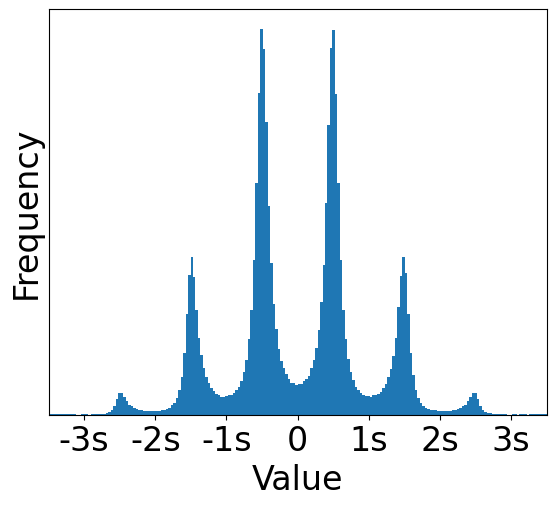

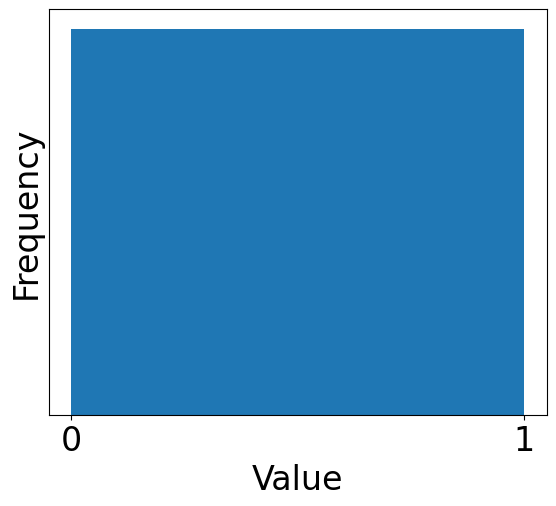

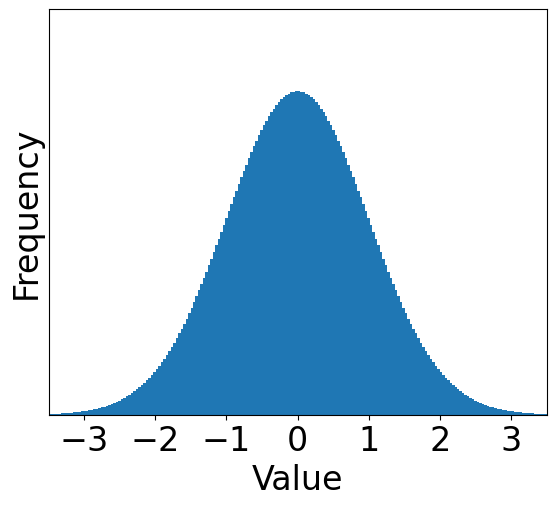

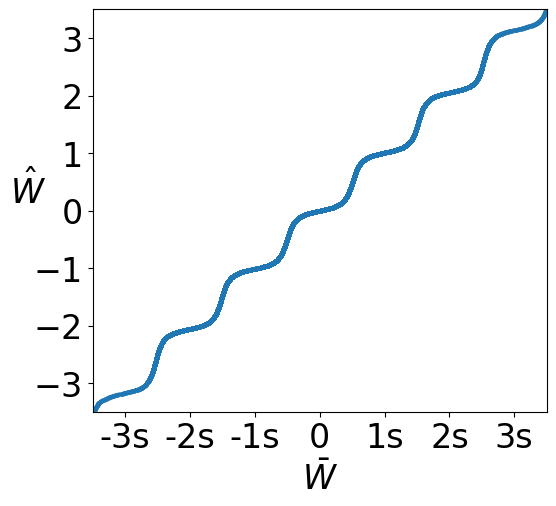

In [10]:
import torch, matplotlib.pyplot as plt
from models.quantization.base_linear import OPTIMAL_GAUSSIAN_SCALES
from optimizer.project import project_to_gaussian

# increase font size
plt.rcParams.update({'font.size': 24})

H = 5.5
W = 5
        
exp = BaselineExperiment(name="Baseline", epochs=200)
for i in range(90):
    exp.step()
    

# fig, axs = plt.subplots(1, 4, figsize=(4 * H, W))

# generate oscillating weights
# ax = axs[0]
fig, ax = plt.subplots(1, 1, figsize=(H, W))
wbar = exp.w.cpu().detach()
s = exp.s
ax.hist(wbar.cpu().numpy().flatten(), bins=200, range=(-3.5 * s, 3.5 * s), density=True)
ax.set_xlim(-3.5 * s, 3.5 * s)
# ax.set_ylim(0, 0.5)
ax.set_xticks([i * s  for i in range(-3, 4)], [f"{i}s" if i != 0 else "0" for i in range(-3, 4)])
ax.set_yticks([])
# ax.set_title(r"$\text{vec}(\bar{W})$")
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
# ax.set_box_aspect(1)
fig.tight_layout(pad=0.2, w_pad=0.2, h_pad=0.2)
plt.savefig("cewt1.png", dpi=300, bbox_inches="tight", pad_inches=0.01)

# rank and normalization
# ax = axs[1]
fig, ax = plt.subplots(1, 1, figsize=(H, W))
indices = torch.argsort(wbar.flatten(), descending=False)
order = torch.zeros_like(indices)
order[indices] = torch.arange(indices.numel(), device=wbar.device, dtype=order.dtype)
order = (order.to(torch.float64) + 0.5) * (1 / order.numel())
ax.hist(order.cpu().numpy().flatten(), bins=200, density=True)
ax.set_xticks([0, 1])
ax.set_yticks([])
# ax.set_title(r"$\frac{1}{mn}\left(\text{ranks}(\text{vec}(\bar{W})) + 0.5\right)$")
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
# ax.set_box_aspect(1)
fig.tight_layout(pad=0.2, w_pad=0.2, h_pad=0.2)
plt.savefig("cewt2.png", dpi=300, bbox_inches="tight", pad_inches=0.01)

# ax = axs[2]
fig, ax = plt.subplots(1, 1, figsize=(H, W))
what = (torch.erfinv(2 * order - 1) * (2 ** 0.5))
ax.hist(what.cpu().numpy().flatten(), bins=200, range=(-3.5, 3.5), density=True)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(0, 0.5)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([])
# ax.set_title(r"$\text{vec}(\hat{W})$")
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
# ax.set_box_aspect(1)
fig.tight_layout(pad=0.2, w_pad=0.2, h_pad=0.2)
plt.savefig("cewt3.png", dpi=300, bbox_inches="tight", pad_inches=0.01)

# ax = axs[3]
fig, ax = plt.subplots(1, 1, figsize=(H, W))
ax.scatter(wbar.cpu().numpy().flatten(), what.cpu().numpy().flatten(), alpha=0.1, s=5)
ax.set_ylim(-3.5, 3.5)
ax.set_xlim(-3.5 * s, 3.5 * s)
# circle = plt.Circle((-0.5, -0.5), 1, fill=False, linestyle=":",)
# ax.add_patch(circle)
ax.set_xticks([i * s  for i in range(-3, 4)], [f"{i}s" if i != 0 else "0" for i in range(-3, 4)])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_ylabel(r"$\hat{W}$", rotation=0)
ax.set_xlabel(r"$\bar{W}$")
# ax.set_title(r"$\bar{W} \rightarrow \hat{W}$")
# ax.set_box_aspect(1)
fig.tight_layout(pad=0.2, w_pad=0.2, h_pad=0.2)
plt.savefig("cewt4.png", dpi=300, )


In [12]:
duplicated_exps = [
    [BaselineExperiment(name="STE", epochs=epochs, seed=s) for s in range(5)],
    [BaselineExperiment(name="STE + CEWT", epochs=epochs, hyperball_constraint="gaussian", seed=s) for s in range(5)],
    [HTGEExperiment(name="HTGE", epochs=epochs, alpha_schedule=lambda epoch: epoch / epochs * 9.9 + 0.1, seed=s) for s in range(5)],
    [HTGEExperiment(name="HTGE + CEWT", epochs=epochs, alpha_schedule=lambda epoch: epoch / epochs * 9.9 + 0.1, hyperball_constraint="gaussian", seed=s) for s in range(5)],
    [JacQuantProbe(name="JacQuantProbe", epochs=epochs, sigma_scheduler=lambda epoch: (1 - epoch / epochs) * 0.2 + 1e-4, seed=s) for s in range(5)],
    [JacQuantProbe(name="JacQuantProbe + CEWT", epochs=epochs, sigma_scheduler=lambda epoch: (1 - epoch / epochs) * 0.2 + 1e-4, hyperball_constraint="gaussian", seed=s) for s in range(5)],
    [EWGSExperiment(name="EWGS", epochs=epochs, period=1, iterations=5, seed=s) for s in range(5)],
    [EWGSExperiment(name="EWGS + CEWT", epochs=epochs, period=1, iterations=5, hyperball_constraint="gaussian", seed=s) for s in range(5)],
]


for epoch in range(epochs + 1):
    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
    if epoch >= epochs:
        break
    for duexp in duplicated_exps:
        for exp in duexp:
            exp.step()

Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0795 w[0, 0]=-0.0108
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0182 w[0, 0]=-0.0446
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=-0.0057 w[0, 0]=0.0128
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0221 w[0, 0]=-0.0014
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.0125 w[0, 0]=0.0145
Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0795 w[0, 0]=-0.0108
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0182 w[0, 0]=-0.0446
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=-0.0057 w[0, 0]=0.0128
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0221 w[0, 0]=-0.0014
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.

In [15]:
for duexp in duplicated_exps:
    eval_losses = torch.Tensor([exp.eval_loss().item() for exp in duexp])
    proxy_losses = torch.Tensor([exp.eval_proxy().item() for exp in duexp])
    rbm = torch.Tensor([exp.rbm().item() for exp in duexp])
    ema_freq = torch.Tensor([exp.oscillation_frequency.mean().item() for exp in duexp])
    eval_loss_mean = round(eval_losses.mean().item() * 1e3)
    eval_loss_two_std = round(2 * eval_losses.std().item() * 1e3)
    rbm_mean = round(rbm.mean().item() * 1e3)
    rbm_two_std = round(2 * rbm.std().item() * 1e3)
    ema_freq_mean = round(ema_freq.mean().item() * 1e4)
    ema_freq_two_std = round(2 * ema_freq.std().item() * 1e4)
    print(
        "=========\n", 
        duexp[0].name, 
        f"\nEval Loss: {eval_loss_mean}±{eval_loss_two_std}", 
        f"\nRBM: {rbm_mean}±{rbm_two_std}",
        f"\nEMA Oscillation Frequency: {ema_freq_mean}±{ema_freq_two_std}",
        "\n\n",
    )

 STE 
Eval Loss: 81±0 
RBM: 573±1 
EMA Oscillation Frequency: 701±2 


 STE + CEWT 
Eval Loss: 45±0 
RBM: 10±0 
EMA Oscillation Frequency: 17±0 


 HTGE 
Eval Loss: 53±0 
RBM: 177±1 
EMA Oscillation Frequency: 245±1 


 HTGE + CEWT 
Eval Loss: 46±0 
RBM: 10±0 
EMA Oscillation Frequency: 30±0 


 JacQuantProbe 
Eval Loss: 63±0 
RBM: 349±1 
EMA Oscillation Frequency: 511±2 


 JacQuantProbe + CEWT 
Eval Loss: 52±0 
RBM: 10±0 
EMA Oscillation Frequency: 37±0 


 EWGS 
Eval Loss: 61±0 
RBM: 324±1 
EMA Oscillation Frequency: 392±1 


 EWGS + CEWT 
Eval Loss: 51±0 
RBM: 10±0 
EMA Oscillation Frequency: 13±0 




In [27]:
duplicated_exps = [
    *[[BaselineExperiment(name=f"STE (n={n})", epochs=epochs, n=n, seed=s) for s in range(5)] for n in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]],
    *[[BaselineExperiment(name=f"CEWT (n={n})", epochs=epochs, n=n, hyperball_constraint="gaussian", seed=s) for s in range(5)] for n in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]],
]


for epoch in range(epochs + 1):
    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
    if epoch >= epochs:
        break
    for duexp in duplicated_exps:
        for exp in duexp:
            exp.step()

Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0057 w[0, 0]=0.0110
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0198 w[0, 0]=0.0053
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=0.0708 w[0, 0]=-0.0299
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0161 w[0, 0]=0.0515
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.0092 w[0, 0]=0.0510
Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0057 w[0, 0]=0.0110
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0198 w[0, 0]=0.0053
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=0.0708 w[0, 0]=-0.0299
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0161 w[0, 0]=0.0515
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.0092 w

In [28]:
for duexp in duplicated_exps:
    eval_losses = torch.Tensor([exp.eval_loss().item() for exp in duexp])
    proxy_losses = torch.Tensor([exp.eval_proxy().item() for exp in duexp])
    rbm = torch.Tensor([exp.rbm().item() for exp in duexp])
    eval_loss_mean = round(eval_losses.mean().item() * 1e3)
    eval_loss_two_std = round(2 * eval_losses.std().item() * 1e3)
    rbm_mean = round(rbm.mean().item() * 1e3)
    rbm_two_std = round(2 * rbm.std().item() * 1e3)
    print(
        "=========\n", 
        duexp[0].name, 
        f"\nEval Loss: {eval_loss_mean}±{eval_loss_two_std}", 
        f"\nRBM: {rbm_mean}±{rbm_two_std}",
        "\n\n",
    )

 STE (n=1) 
Eval Loss: 1±0 
RBM: 11±0 


 STE (n=2) 
Eval Loss: 1±0 
RBM: 12±0 


 STE (n=4) 
Eval Loss: 1±0 
RBM: 15±0 


 STE (n=8) 
Eval Loss: 2±0 
RBM: 19±0 


 STE (n=16) 
Eval Loss: 3±0 
RBM: 27±0 


 STE (n=32) 
Eval Loss: 4±0 
RBM: 40±0 


 STE (n=64) 
Eval Loss: 7±0 
RBM: 64±0 


 STE (n=128) 
Eval Loss: 13±0 
RBM: 108±1 


 STE (n=256) 
Eval Loss: 23±0 
RBM: 186±0 


 STE (n=512) 
Eval Loss: 44±0 
RBM: 332±1 


 STE (n=1024) 
Eval Loss: 81±0 
RBM: 573±1 


 CEWT (n=1) 
Eval Loss: 1±0 
RBM: 10±0 


 CEWT (n=2) 
Eval Loss: 1±0 
RBM: 10±0 


 CEWT (n=4) 
Eval Loss: 1±0 
RBM: 10±0 


 CEWT (n=8) 
Eval Loss: 2±0 
RBM: 10±0 


 CEWT (n=16) 
Eval Loss: 2±0 
RBM: 10±0 


 CEWT (n=32) 
Eval Loss: 3±0 
RBM: 10±0 


 CEWT (n=64) 
Eval Loss: 5±0 
RBM: 10±0 


 CEWT (n=128) 
Eval Loss: 9±0 
RBM: 10±0 


 CEWT (n=256) 
Eval Loss: 14±0 
RBM: 10±0 


 CEWT (n=512) 
Eval Loss: 25±0 
RBM: 10±0 


 CEWT (n=1024) 
Eval Loss: 45±0 
RBM: 10±0 




In [29]:
duplicated_exps = [
    *[[BaselineExperiment(name=f"STE (epochs={epochs})", epochs=epochs, seed=s) for s in range(5)] for epochs in [1, 3, 6, 12, 25, 50, 100, 200]],
    *[[BaselineExperiment(name=f"CEWT (epochs={epochs})", epochs=epochs, hyperball_constraint="gaussian", seed=s) for s in range(5)] for epochs in [1, 3, 6, 12, 25, 50, 100, 200]],
]


for epoch in range(200 + 1):
    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
    if epoch >= 200:
        break
    for duexp in duplicated_exps:
        for exp in duexp:
            if exp.curr_epoch < exp.epochs:
                exp.step()

Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0795 w[0, 0]=-0.0108
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0182 w[0, 0]=-0.0446
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=-0.0057 w[0, 0]=0.0128
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0221 w[0, 0]=-0.0014
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.0125 w[0, 0]=0.0145
Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0795 w[0, 0]=-0.0108
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.0182 w[0, 0]=-0.0446
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=-0.0057 w[0, 0]=0.0128
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.0221 w[0, 0]=-0.0014
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.

In [30]:
for duexp in duplicated_exps:
    eval_losses = torch.Tensor([exp.eval_loss().item() for exp in duexp])
    proxy_losses = torch.Tensor([exp.eval_proxy().item() for exp in duexp])
    rbm = torch.Tensor([exp.rbm().item() for exp in duexp])
    eval_loss_mean = round(eval_losses.mean().item() * 1e3)
    eval_loss_two_std = round(2 * eval_losses.std().item() * 1e3)
    rbm_mean = round(rbm.mean().item() * 1e3)
    rbm_two_std = round(2 * rbm.std().item() * 1e3)
    print(
        "=========\n", 
        duexp[0].name, 
        f"\nEval Loss: {eval_loss_mean}±{eval_loss_two_std}", 
        f"\nRBM: {rbm_mean}±{rbm_two_std}",
        "\n\n",
    )

 STE (epochs=1) 
Eval Loss: 1847±10 
RBM: 12±0 


 STE (epochs=3) 
Eval Loss: 1609±9 
RBM: 14±0 


 STE (epochs=6) 
Eval Loss: 1277±7 
RBM: 17±0 


 STE (epochs=12) 
Eval Loss: 747±5 
RBM: 19±0 


 STE (epochs=25) 
Eval Loss: 244±1 
RBM: 26±0 


 STE (epochs=50) 
Eval Loss: 90±0 
RBM: 98±1 


 STE (epochs=100) 
Eval Loss: 82±0 
RBM: 378±1 


 STE (epochs=200) 
Eval Loss: 81±0 
RBM: 573±1 


 CEWT (epochs=1) 
Eval Loss: 1839±9 
RBM: 10±0 


 CEWT (epochs=3) 
Eval Loss: 1625±9 
RBM: 10±0 


 CEWT (epochs=6) 
Eval Loss: 1343±7 
RBM: 10±0 


 CEWT (epochs=12) 
Eval Loss: 859±6 
RBM: 10±0 


 CEWT (epochs=25) 
Eval Loss: 281±1 
RBM: 10±0 


 CEWT (epochs=50) 
Eval Loss: 107±0 
RBM: 10±0 


 CEWT (epochs=100) 
Eval Loss: 63±0 
RBM: 10±0 


 CEWT (epochs=200) 
Eval Loss: 45±0 
RBM: 10±0 




In [33]:
duplicated_exps = [
    *[[BaselineExperiment(name=f"STE (d={d})", d=d, seed=s) for s in range(5)] for d in [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]],
    *[[BaselineExperiment(name=f"CEWT (d={d})", d=d, hyperball_constraint="gaussian", seed=s) for s in range(5)] for d in [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]],
]


for epoch in range(200 + 1):
    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
    if epoch >= 200:
        break
    for duexp in duplicated_exps:
        for exp in duexp:
            if exp.curr_epoch < exp.epochs:
                exp.step()

Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.1279 w[0, 0]=1.7989
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.4483 w[0, 0]=-0.4108
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=1.6029 w[0, 0]=-0.1290
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.3650 w[0, 0]=-0.5008
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.2078 w[0, 0]=-0.2839
Experiment BaselineExperiment initialized with seed 0 x[0, 0]=-0.9247 q*[0, 0]=0.0904 w[0, 0]=1.2720
Experiment BaselineExperiment initialized with seed 1 x[0, 0]=-0.2963 q*[0, 0]=-0.3170 w[0, 0]=-0.2905
Experiment BaselineExperiment initialized with seed 2 x[0, 0]=0.0223 q*[0, 0]=1.1334 w[0, 0]=-0.0912
Experiment BaselineExperiment initialized with seed 3 x[0, 0]=0.4263 q*[0, 0]=-0.2581 w[0, 0]=-0.3541
Experiment BaselineExperiment initialized with seed 4 x[0, 0]=-1.9505 q*[0, 0]=-0.1

In [34]:
for duexp in duplicated_exps:
    eval_losses = torch.Tensor([exp.eval_loss().item() for exp in duexp])
    proxy_losses = torch.Tensor([exp.eval_proxy().item() for exp in duexp])
    rbm = torch.Tensor([exp.rbm().item() for exp in duexp])
    eval_loss_mean = round(eval_losses.mean().item() * 1e3)
    eval_loss_two_std = round(2 * eval_losses.std().item() * 1e3)
    rbm_mean = round(rbm.mean().item() * 1e3)
    rbm_two_std = round(2 * rbm.std().item() * 1e3)
    print(
        "=========\n", 
        duexp[0].name, 
        f"\nEval Loss: {eval_loss_mean}±{eval_loss_two_std}", 
        f"\nRBM: {rbm_mean}±{rbm_two_std}",
        "\n\n",
    )

 STE (d=2) 
Eval Loss: 398±452 
RBM: 600±671 


 STE (d=4) 
Eval Loss: 258±352 
RBM: 775±244 


 STE (d=8) 
Eval Loss: 130±47 
RBM: 756±114 


 STE (d=16) 
Eval Loss: 137±38 
RBM: 753±52 


 STE (d=32) 
Eval Loss: 128±37 
RBM: 741±40 


 STE (d=64) 
Eval Loss: 128±6 
RBM: 733±21 


 STE (d=128) 
Eval Loss: 122±2 
RBM: 712±5 


 STE (d=256) 
Eval Loss: 117±1 
RBM: 693±2 


 STE (d=512) 
Eval Loss: 105±1 
RBM: 661±1 


 STE (d=1024) 
Eval Loss: 81±0 
RBM: 573±1 


 CEWT (d=2) 
Eval Loss: 1849±2115 
RBM: 0±0 


 CEWT (d=4) 
Eval Loss: 1876±1619 
RBM: 0±0 


 CEWT (d=8) 
Eval Loss: 313±281 
RBM: 13±34 


 CEWT (d=16) 
Eval Loss: 117±41 
RBM: 11±9 


 CEWT (d=32) 
Eval Loss: 95±8 
RBM: 11±4 


 CEWT (d=64) 
Eval Loss: 90±4 
RBM: 10±1 


 CEWT (d=128) 
Eval Loss: 85±1 
RBM: 10±0 


 CEWT (d=256) 
Eval Loss: 79±1 
RBM: 10±0 


 CEWT (d=512) 
Eval Loss: 66±0 
RBM: 10±0 


 CEWT (d=1024) 
Eval Loss: 45±0 
RBM: 10±0 




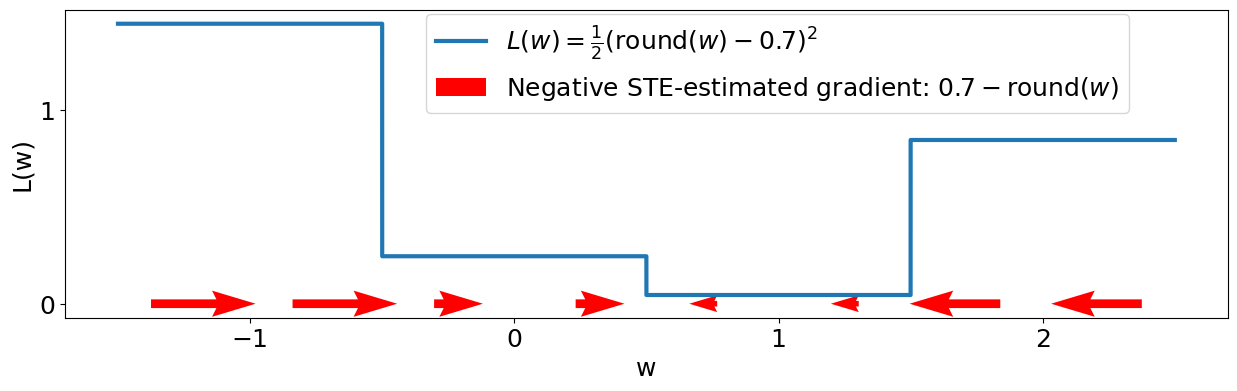

In [8]:
import torch, matplotlib.pyplot as plt, math

plt.rcParams["font.size"] = 18

fig = plt.figure(figsize=(5 * 3, 4))
ax = fig.add_subplot(111)

wcs = list(range(-1, 3))
w = []
bound = 0.4999
steps = 100
offset = 0
for wc in wcs:
    w.append(torch.linspace(wc - bound, wc + bound, steps) - offset)
w = torch.cat(w)

q = torch.round(w)
l = (q - 0.7) ** 2 / 2
ste_grad = q - 0.7
b = l - ste_grad * q
l2 = ste_grad * w + b

label = r"$L(w)=\frac{1}{2}(\text{round}(w) - 0.7)^2$"
ax.plot(w, l, linewidth=3, label=label)
w = torch.linspace(-1.4999 + 0.125, 2.49999 - 0.125, 8)
q = torch.round(w)
ste_grad = q - 0.7
mag = torch.clamp(ste_grad.abs(), min=0.4, max=1.5)
ste_grad = ste_grad / ste_grad.abs() * mag * 1.5
ax.quiver(w, torch.zeros_like(w), -ste_grad, torch.zeros_like(w), color="red", scale=25, label=r"Negative STE-estimated gradient: $0.7 - \text{round}(w)$")
ax.set_xticks(wcs)
ax.set_yticks(list(range(0, 2)))
ax.set_xlabel("w")
ax.set_ylabel("L(w)")
fig.legend(loc="upper center", ncols=1, bbox_to_anchor=(0.6, 0.9))
plt.savefig("exp_1d.png", dpi=300, bbox_inches="tight")

tensor([ 0.0450,  0.2450,  0.5450,  0.7450,  2.0450,  2.2450,  4.5450,  4.7450,
         8.0450,  8.2450,  8.8450,  9.4450, 13.3450, 13.9450, 18.8450, 19.4450,
        25.3450, 25.9450, 32.8450, 33.4450]) tensor(0.0450)


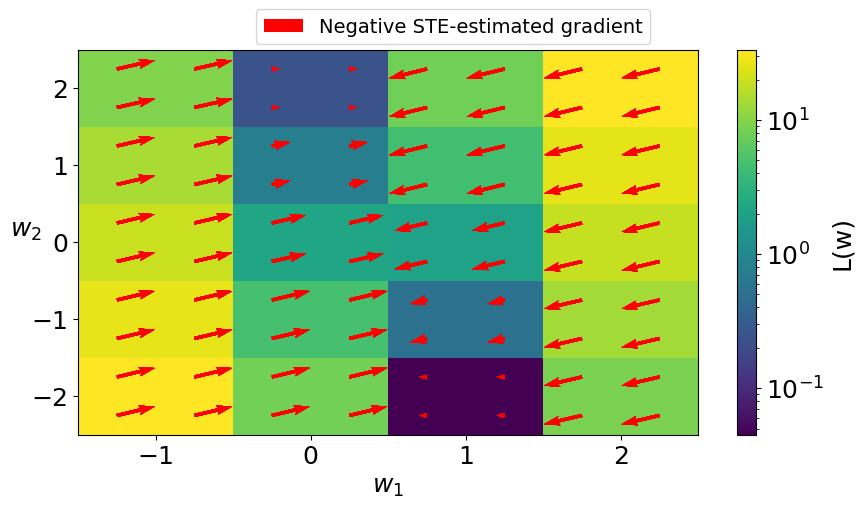

In [17]:
import torch, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams["font.size"] = 18

wcs = list(range(-1, 3))
wc2s = list(range(-2, 3))

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
# ax = fig.add_subplot(111, projection='3d')
first = True

w = []
w2 = []

bound = 1 / 4
steps = 2
offset = 0
for wc in wcs:
    for wc2 in wc2s:
        w.append(torch.linspace(wc - bound, wc + bound, steps) - offset)
        w2.append(torch.linspace(wc2 - bound, wc2 + bound, steps) - offset)

w = torch.cat(w)
w2 = torch.cat(w2)
w, w2 = torch.meshgrid(w, w2)
q, q2 = torch.round(w).int(), torch.round(w2).int()

first_row = (q - 0.7)
second_row = (4 * q + q2 - 2)

l = (first_row ** 2) / 2 + (second_row ** 2) / 2
print(torch.unique(l), l.min())

ste_grad = first_row + second_row * 4
ste_grad2 = first_row * 0 + second_row

plot = ax.pcolormesh(w, w2, l, cmap="viridis", norm=LogNorm(vmin=l.min(), vmax=l.max()))
label = r"$\frac{1}{2} (q_1 - 0.7)^2 + \frac{1}{2}(4q_1 + q_2 - 2)^2$"
label += "\n"
label += r"$\text{ where } q_1 = \text{round}(w_1)$"
label += "\n"
label += r"$\text{ and } q_2 = \text{round}(w_2)$"
cbar = plt.colorbar(plot, ax=ax)
cbar.set_label("L(w)")

magnitude = torch.sqrt(ste_grad ** 2 + ste_grad2 ** 2)
clamped_magnitude = torch.clamp(magnitude, min=2, max=10)
ste_grad = ste_grad / magnitude * clamped_magnitude
ste_grad2 = ste_grad2 / magnitude * clamped_magnitude
plot = ax.quiver(w, w2, -ste_grad, -ste_grad2, scale=160, color="red", label="Negative STE-estimated gradient", width=0.005) 

# ax.vlines(x=torch.Tensor(wc2s[:-1]) + 0.5, ymin=wcs[0] - 0.5, ymax=wcs[-1] + 0.5, color="black", linestyle="--")
# ax.hlines(y=torch.Tensor(wcs[:-1]) + 0.5, xmin=wc2s[0] - 0.5, xmax=wc2s[-1] + 0.5, color="black", linestyle="--")
# fig.colorbar(plot, ax=ax, label="STE Gradient magnitude")

if first:
    first = False

fig.legend(loc="upper center", ncols=1, bbox_to_anchor=(0.5, 0.98), fontsize=14)
ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$", rotation=0)
ax.set_yticks(wc2s)
ax.set_xticks(wcs)
plt.savefig("exp_2d.png", dpi=300, bbox_inches="tight")